# Topic modeling of all tweets

## Load and preprocess data

In [1]:
!pip install pandas numpy scikit-learn gensim pyLDAvis matplotlib seaborn plotly


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /Users/sonia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/sonia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/sonia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
df = pd.read_csv('tweets.csv')
tweets = df['text'].dropna().astype(str).tolist()

with open('stopwords.txt', 'r') as f:
    custom_stopwords = set([line.strip().lower() for line in f])

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_text(text):
    """Clean and preprocess tweet text"""
    # Remove URLs, mentions, and hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()

    # Tokenize and lemmatize
    tokens = text.split()
    lemmatized_tokens = []

    for token in tokens:
        if len(token) > 2 and token not in custom_stopwords:
            pos = get_wordnet_pos(token)
            lemma = lemmatizer.lemmatize(token, pos=pos)
            lemmatized_tokens.append(lemma)

    return ' '.join(lemmatized_tokens)

# Apply preprocessing
processed_tweets = [preprocess_text(tweet) for tweet in tweets]

## LDA

### Document-term matrix

In [4]:
# Create document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm = vectorizer.fit_transform(processed_tweets)
feature_names = vectorizer.get_feature_names_out()

print(f"Number of tweets: {len(processed_tweets)}")
print(f"Vocabulary size: {len(feature_names)}")

Number of tweets: 65378
Vocabulary size: 1000


### Test number of topics

In [ ]:
# Optimize Topic Model Parameters
print("OPTIMIZING TOPIC MODEL SETTINGS")
print("=" * 60)

# Strategy 1: Try different numbers of topics
print("\n1. TESTING DIFFERENT NUMBER OF TOPICS:")
print("-" * 40)

topic_range = [5, 8, 10, 12, 15, 20, 25]
coherence_scores = []
perplexity_scores = []

for n in topic_range:
    # Create and fit LDA with n topics
    lda_temp = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        max_iter=20,
        learning_method='online',
        learning_offset=50.
    )
    lda_temp.fit(dtm)

    # Calculate coherence (simplified version)
    doc_topic_temp = lda_temp.transform(dtm)
    dominant_temp = doc_topic_temp.argmax(axis=1)
    avg_concentration = np.mean(np.max(doc_topic_temp, axis=1))

    # Calculate simplified coherence
    topic_word_matrix = lda_temp.components_
    n_top_words = 10
    topic_words = []
    for topic_idx in range(n):
        top_features_ind = topic_word_matrix[topic_idx].argsort()[:-n_top_words - 1:-1]
        topic_words.append([feature_names[i] for i in top_features_ind])

    # Store scores
    coherence_scores.append(avg_concentration)
    perplexity_scores.append(lda_temp.perplexity(dtm))

    print(f"n_topics={n:2d}: Avg concentration={avg_concentration:.3f}, Perplexity={lda_temp.perplexity(dtm):.1f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(topic_range, coherence_scores, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Average Topic Concentration')
ax1.set_title('Topic Clarity vs. Number of Topics')
ax1.grid(True, alpha=0.3)

ax2.plot(topic_range, perplexity_scores, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Topics')
ax2.set_ylabel('Perplexity')
ax2.set_title('Model Fit vs. Number of Topics')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Strategy 2: Adjust LDA parameters
print("\n2. OPTIMIZING LDA PARAMETERS:")
print("-" * 40)

# Test different learning parameters
param_configs = [
    {'learning_method': 'batch', 'max_iter': 50, 'doc_topic_prior': 0.1},
    {'learning_method': 'online', 'max_iter': 30, 'learning_offset': 100, 'batch_size': 128},
    {'learning_method': 'online', 'max_iter': 50, 'learning_offset': 50, 'batch_size': 256},
    {'learning_method': 'online', 'max_iter': 100, 'learning_offset': 25}
]

for i, params in enumerate(param_configs):
    lda_test = LatentDirichletAllocation(
        n_components=10,  # Use intermediate number
        random_state=42,
        **params
    )
    lda_test.fit(dtm)
    doc_topic_test = lda_test.transform(dtm)
    avg_conc = np.mean(np.max(doc_topic_test, axis=1))
    print(f"Config {i+1}: Avg concentration={avg_conc:.3f}, Perplexity={lda_test.perplexity(dtm):.1f}")

### LDA model

In [5]:
n_topics = 10
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    learning_method='online',
    learning_offset=50.
)

lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",50.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


### Analyze topic

In [7]:
# Analyze topic distributions
def display_topics(model, feature_names, n_top_words=10):
    """Display top words for each topic"""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics[f'Topic_{topic_idx}'] = top_features
        print(f"Topic {topic_idx}:")
        print(" ".join(top_features))
        print()
    return topics

# Display topics
topics = display_topics(lda, feature_names, n_top_words=10)

# Get document-topic distributions
doc_topic_dist = lda.transform(dtm)
dominant_topics = doc_topic_dist.argmax(axis=1)

# Calculate topic dominance
topic_dominance = np.bincount(dominant_topics, minlength=n_topics)
topic_percentages = (topic_dominance / len(dominant_topics)) * 100

Topic 0:
twitter model news true bring tomorrow home hear stay stop

Topic 1:
ceo amaze watch san today world city marc celebrate great

Topic 2:
tesla love great day spacex verizon game wait video check

Topic 3:
work change service lot people read today high great hard

Topic 4:
business company covid support important employee vaccine continue call test

Topic 5:
excite people launch good connect partnership live care find country

Topic 6:
start give industry million cover kid homeless erdayastronaut tree school

Topic 7:
time year week happy car impact family place ready day

Topic 8:
salesforce team proud join work future share great partner congratulation

Topic 9:
tmobile world customer big learn part experience network data technology



In [8]:
# Analyze topic overlap and distinctness
# Create topic-term matrix for analysis
topic_term_matrix = lda.components_

# Calculate cosine similarity between topics
from sklearn.metrics.pairwise import cosine_similarity

topic_similarity = cosine_similarity(topic_term_matrix)

print("Topic Similarity Matrix (Top 5 most similar topics per row):")
print("-" * 60)
for i in range(n_topics):
    similarities = topic_similarity[i]
    # Get indices of top 5 similar topics (excluding self)
    similar_indices = similarities.argsort()[-6:-1][::-1]
    print(f"Topic {i}: Most similar to topics {list(similar_indices)}")
print()

# Find terms that appear in multiple topics
term_topic_counts = np.sum(topic_term_matrix > np.percentile(topic_term_matrix, 75), axis=0)
common_terms = [feature_names[i] for i in np.where(term_topic_counts > 1)[0]]

print(f"Number of terms appearing in multiple topics: {len(common_terms)}")
print("Sample of common terms:", common_terms[:20])

Topic Similarity Matrix (Top 5 most similar topics per row):
------------------------------------------------------------
Topic 0: Most similar to topics [np.int64(5), np.int64(9), np.int64(7), np.int64(4), np.int64(6)]
Topic 1: Most similar to topics [np.int64(9), np.int64(2), np.int64(3), np.int64(7), np.int64(8)]
Topic 2: Most similar to topics [np.int64(1), np.int64(3), np.int64(8), np.int64(9), np.int64(7)]
Topic 3: Most similar to topics [np.int64(8), np.int64(5), np.int64(1), np.int64(2), np.int64(7)]
Topic 4: Most similar to topics [np.int64(9), np.int64(3), np.int64(8), np.int64(5), np.int64(1)]
Topic 5: Most similar to topics [np.int64(3), np.int64(8), np.int64(6), np.int64(1), np.int64(4)]
Topic 6: Most similar to topics [np.int64(5), np.int64(7), np.int64(3), np.int64(8), np.int64(4)]
Topic 7: Most similar to topics [np.int64(3), np.int64(1), np.int64(8), np.int64(5), np.int64(2)]
Topic 8: Most similar to topics [np.int64(3), np.int64(5), np.int64(2), np.int64(1), np.int64(

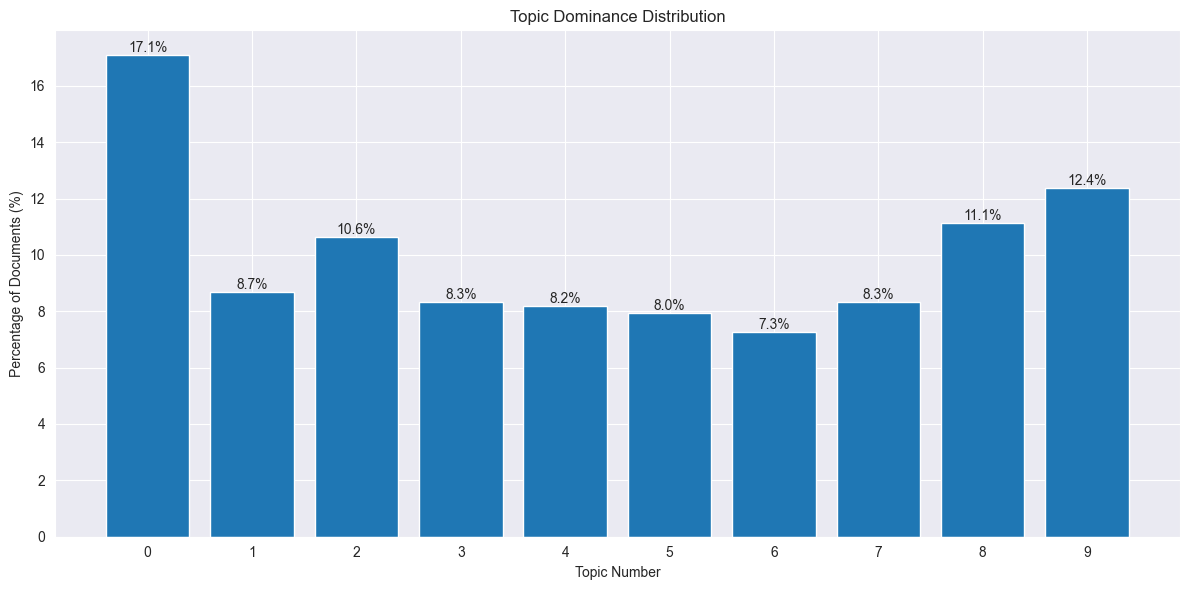

Top 5 Most Dominant Topics:
Topic 0: 17.1% of tweets
Top words: twitter model news true bring

Topic 9: 12.4% of tweets
Top words: tmobile world customer big learn

Topic 8: 11.1% of tweets
Top words: salesforce team proud join work

Topic 2: 10.6% of tweets
Top words: tesla love great day spacex

Topic 1: 8.7% of tweets
Top words: ceo amaze watch san today



In [9]:
# Visualize dominant topics
# Plot topic distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(range(n_topics), topic_percentages)
plt.xlabel('Topic Number')
plt.ylabel('Percentage of Documents (%)')
plt.title('Topic Dominance Distribution')
plt.xticks(range(n_topics))

# Add percentage labels
for bar, percentage in zip(bars, topic_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Display top topics
print("Top 5 Most Dominant Topics:")
dominant_indices = topic_percentages.argsort()[-5:][::-1]
for idx in dominant_indices:
    print(f"Topic {idx}: {topic_percentages[idx]:.1f}% of tweets")
    print(f"Top words: {' '.join(topics[f'Topic_{idx}'][:5])}")
    print()

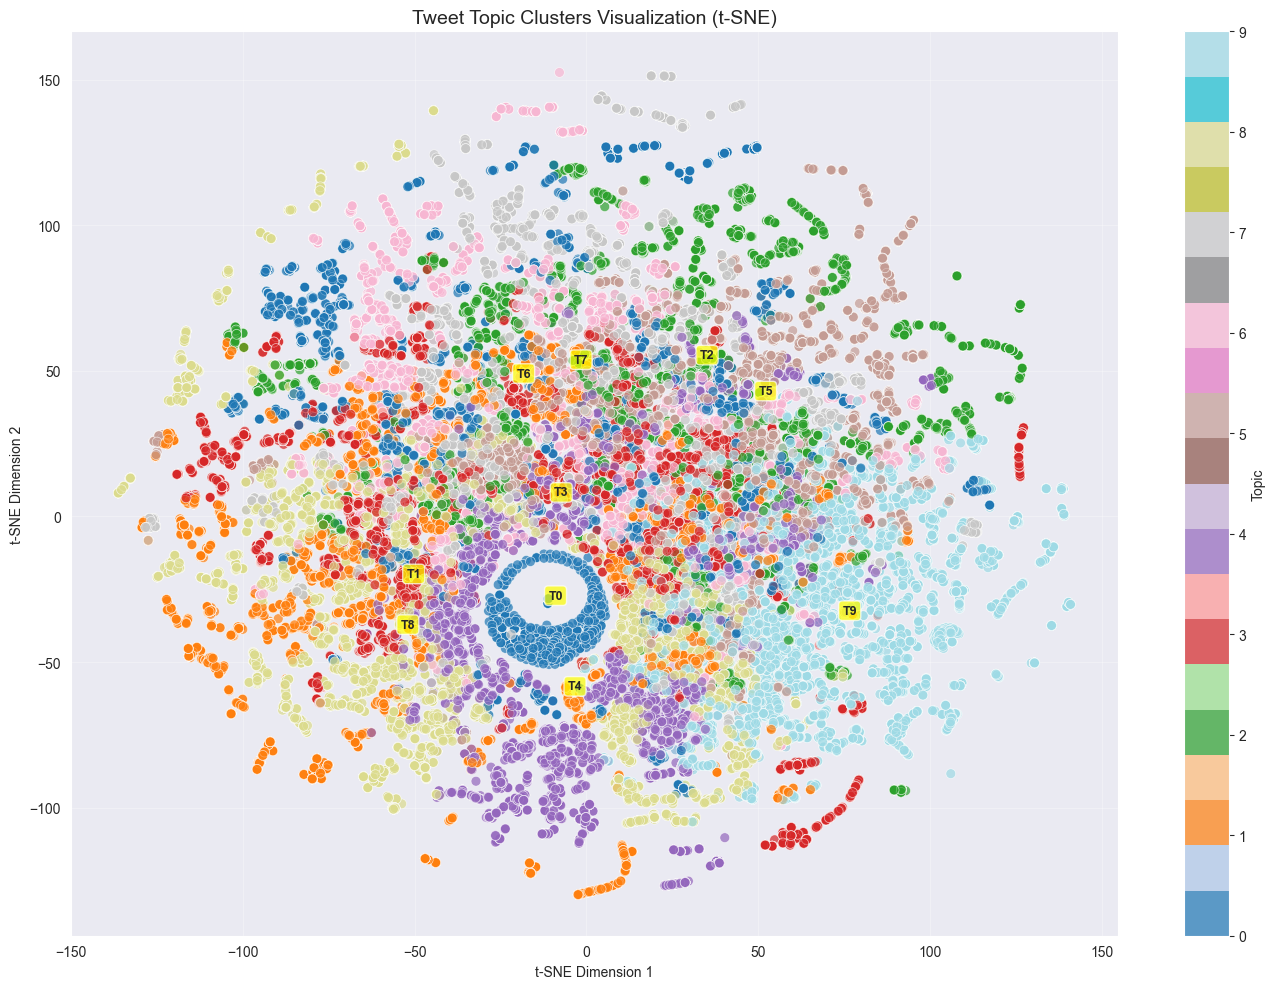

In [10]:
# Visualize clusters with t-SNE
# Reduce dimensionality for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
doc_embeddings_2d = tsne.fit_transform(doc_topic_dist)

# Create visualization dataframe
vis_df = pd.DataFrame({
    'x': doc_embeddings_2d[:, 0],
    'y': doc_embeddings_2d[:, 1],
    'topic': dominant_topics,
    'dominant_topic_prob': doc_topic_dist.max(axis=1)
})

# Plot with matplotlib
plt.figure(figsize=(14, 10))
scatter = plt.scatter(vis_df['x'], vis_df['y'],
                     c=vis_df['topic'],
                     cmap='tab20',
                     alpha=0.7,
                     s=50,
                     edgecolors='w',
                     linewidth=0.5)

plt.colorbar(scatter, label='Topic')
plt.title('Tweet Topic Clusters Visualization (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)

# Add topic labels at cluster centers
for topic in range(n_topics):
    topic_points = vis_df[vis_df['topic'] == topic]
    if len(topic_points) > 0:
        center_x = topic_points['x'].median()
        center_y = topic_points['y'].median()
        plt.annotate(f'T{topic}',
                    (center_x, center_y),
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3",
                             facecolor='yellow',
                             alpha=0.7))

plt.tight_layout()
plt.show()

In [11]:
# Generate topic summary report
print("=" * 80)
print("TOPIC ANALYSIS SUMMARY REPORT")
print("=" * 80)

# 1. Topic dominance summary
print("\n1. TOPIC DOMINANCE:")
for idx in np.argsort(-topic_percentages):
    print(f"Topic {idx:2d}: {topic_percentages[idx]:5.1f}% - {' '.join(topics[f'Topic_{idx}'][:5])}")

# 2. Topic distinctness analysis
print("\n\n2. TOPIC DISTINCTNESS ANALYSIS:")
avg_similarity = np.mean(topic_similarity - np.eye(n_topics))  # Exclude self-similarity
print(f"Average inter-topic similarity: {avg_similarity:.3f}")
print(f"Topics with high similarity (>0.3):")
for i in range(n_topics):
    for j in range(i+1, n_topics):
        if topic_similarity[i, j] > 0.3:
            print(f"  Topic {i} & Topic {j}: {topic_similarity[i, j]:.3f}")

# 3. Common terms analysis
print(f"\n\n3. COMMON TERMS ACROSS TOPICS:")
print(f"Found {len(common_terms)} terms appearing in multiple topics")
print(f"Most common overlapping terms: {', '.join(common_terms[:15])}")

# 4. Cluster quality
print(f"\n\n4. CLUSTER QUALITY:")
print(f"Average confidence per tweet: {vis_df['dominant_topic_prob'].mean():.3f}")
print(f"Tweets with low confidence (<0.5): {(vis_df['dominant_topic_prob'] < 0.5).sum()} ({(vis_df['dominant_topic_prob'] < 0.5).mean()*100:.1f}%)")

print("\n" + "=" * 80)

TOPIC ANALYSIS SUMMARY REPORT

1. TOPIC DOMINANCE:
Topic  0:  17.1% - twitter model news true bring
Topic  9:  12.4% - tmobile world customer big learn
Topic  8:  11.1% - salesforce team proud join work
Topic  2:  10.6% - tesla love great day spacex
Topic  1:   8.7% - ceo amaze watch san today
Topic  3:   8.3% - work change service lot people
Topic  7:   8.3% - time year week happy car
Topic  4:   8.2% - business company covid support important
Topic  5:   8.0% - excite people launch good connect
Topic  6:   7.3% - start give industry million cover


2. TOPIC DISTINCTNESS ANALYSIS:
Average inter-topic similarity: 0.037
Topics with high similarity (>0.3):


3. COMMON TERMS ACROSS TOPICS:
Found 585 terms appearing in multiple topics
Most common overlapping terms: accelerate, accenture, access, achieve, act, action, add, additional, address, advance, advanced, age, aim, air, akamai


4. CLUSTER QUALITY:
Average confidence per tweet: 0.386
Tweets with low confidence (<0.5): 46788 (71.6%)



### Validation

In [ ]:
# Topic Model Validation
print("TOPIC MODEL VALIDATION METRICS")
print("=" * 60)

# 1. Perplexity (lower is better)
perplexity = lda.perplexity(dtm)
print(f"1. Perplexity: {perplexity:.2f}")
print("   (Lower perplexity indicates better generalization)")

# 2. Topic Coherence using UMass measure (higher is better)
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Prepare data for gensim coherence calculation
tokenized_tweets = [tweet.split() for tweet in processed_tweets]
dictionary = Dictionary(tokenized_tweets)
corpus = [dictionary.doc2bow(text) for text in tokenized_tweets]

# Create gensim LDA model for coherence calculation
from gensim.models import LdaModel
gensim_lda = LdaModel(corpus=corpus,
                      id2word=dictionary,
                      num_topics=n_topics,
                      random_state=42,
                      passes=10)

# Calculate coherence
coherence_model = CoherenceModel(model=gensim_lda,
                                 texts=tokenized_tweets,
                                 dictionary=dictionary,
                                 coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f"2. Coherence Score (c_v): {coherence_score:.3f}")
print("   (Higher coherence indicates more interpretable topics)")

# 3. Topic diversity (percentage of unique words across topics)
all_topic_words = []
for topic_idx in range(n_topics):
    top_words_idx = lda.components_[topic_idx].argsort()[-20:][::-1]
    all_topic_words.extend([feature_names[i] for i in top_words_idx])

unique_words_ratio = len(set(all_topic_words)) / len(all_topic_words)
print(f"3. Topic Diversity: {unique_words_ratio:.3f}")
print(f"   ({len(set(all_topic_words))} unique words out of {len(all_topic_words)} total top words)")

# 4. Topic balance (entropy of topic distribution)
topic_entropy = -np.sum(topic_percentages/100 * np.log(topic_percentages/100 + 1e-10))
max_entropy = np.log(n_topics)
normalized_entropy = topic_entropy / max_entropy
print(f"4. Topic Balance (Normalized Entropy): {normalized_entropy:.3f}")
print("   (Higher values indicate more balanced topic distribution)")

# 5. Document-topic concentration
avg_doc_topic_concentration = np.mean(np.max(doc_topic_dist, axis=1))
print(f"5. Average Document-Topic Concentration: {avg_doc_topic_concentration:.3f}")
print("   (Higher values indicate clearer topic assignments)")

# 6. Silhouette score on topic distributions
from sklearn.metrics import silhouette_score
if len(set(dominant_topics)) > 1:
    silhouette = silhouette_score(doc_topic_dist, dominant_topics, metric='cosine')
    print(f"6. Silhouette Score (cosine): {silhouette:.3f}")
    print("   (Higher values indicate better-defined clusters)")

print("\nVALIDATION INTERPRETATION:")
print("-" * 40)
if coherence_score > 0.5:
    print("✓ Good topic interpretability")
else:
    print("⚠ Topic interpretability could be improved")

if unique_words_ratio > 0.7:
    print("✓ Good topic diversity")
else:
    print("⚠ Topics may have too much word overlap")

if normalized_entropy > 0.7:
    print("✓ Balanced topic distribution")
else:
    print("⚠ Topics are imbalanced - some dominate heavily")

if avg_doc_topic_concentration > 0.6:
    print("✓ Clear topic assignments for documents")
else:
    print("⚠ Many documents have ambiguous topic assignments")

## BERT

In [12]:
!pip install bertopic sentence-transformers umap-learn hdbscan

  Using cached hdbscan-0.8.40-cp313-cp313-macosx_10_13_universal2.whl

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [14]:
df = pd.read_csv('tweets.csv')
tweets = df['text'].dropna().astype(str).tolist()
print(f"Loaded {len(tweets)} tweets")

Loaded 65378 tweets


In [15]:
# Initialize BERTopic model with optimal settings for tweets
print("INITIALIZING BERTopic MODEL FOR TWEET ANALYSIS")
print("=" * 60)

# Choose embedding model - optimized for short text
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")  # Good balance of speed and quality

# Configure UMAP for dimensionality reduction (tuned for short text)
umap_model = UMAP(
    n_neighbors=15,           # Smaller for short text
    n_components=5,           # Lower dimensionality
    min_dist=0.0,             # Allows tighter clusters
    metric='cosine',
    random_state=42
)

# Configure HDBSCAN for clustering (tuned for social media text)
hdbscan_model = HDBSCAN(
    min_cluster_size=10,      # Smaller clusters for tweets
    min_samples=5,            # Lower for short text
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Configure vectorizer for topic representation
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),       # Include bigrams for context
    min_df=2,                 # Minimum document frequency
    max_features=3000         # Limit vocabulary size
)

# Initialize BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,           # Top words per topic
    min_topic_size=15,        # Minimum tweets per topic
    nr_topics=5,              # Target number of topics (based on LDA results)
    calculate_probabilities=True,
    verbose=True
)

print("Model initialized with settings optimized for tweet analysis")
print(f"• Embedding model: all-MiniLM-L6-v2")
print(f"• Target topics: 5")
print(f"• Minimum topic size: 15 tweets")

INITIALIZING BERTopic MODEL FOR TWEET ANALYSIS
Model initialized with settings optimized for tweet analysis
• Embedding model: all-MiniLM-L6-v2
• Target topics: 5
• Minimum topic size: 15 tweets


In [ ]:
# Fit BERTopic model and extract topics
print("FITTING BERTopic MODEL...")
print("=" * 60)

# Fit and transform
topics, probabilities = topic_model.fit_transform(tweets)

# Get topic information
topic_info = topic_model.get_topic_info()
print("\nTOPIC DISCOVERY RESULTS:")
print("=" * 60)
print(topic_info)

print(f"\nNumber of topics discovered: {len(topic_info) - 1}")  # Subtract -1 topic
print(f"Outliers (Topic -1): {topic_info.loc[0, 'Count']} tweets")

In [ ]:
# Analyze and visualize topic keywords
print("TOPIC KEYWORD ANALYSIS")
print("=" * 60)

# Get all topics (excluding outliers)
all_topics = sorted(topic_info['Topic'].tolist())
all_topics = [t for t in all_topics if t != -1]

print("\nTOPIC KEYWORDS (Top 10 per topic):")
print("-" * 60)

for topic in all_topics:
    topic_words = topic_model.get_topic(topic)
    words = [word for word, _ in topic_words[:10]]
    count = topic_info[topic_info['Topic'] == topic]['Count'].values[0]
    print(f"\nTopic {topic} ({count} tweets):")
    print("  " + ", ".join(words))

    # Show representative tweets
    topic_indices = [i for i, t in enumerate(topics) if t == topic]
    if topic_indices:
        print(f"  Sample tweet: '{tweets[topic_indices[0]][:80]}...'")

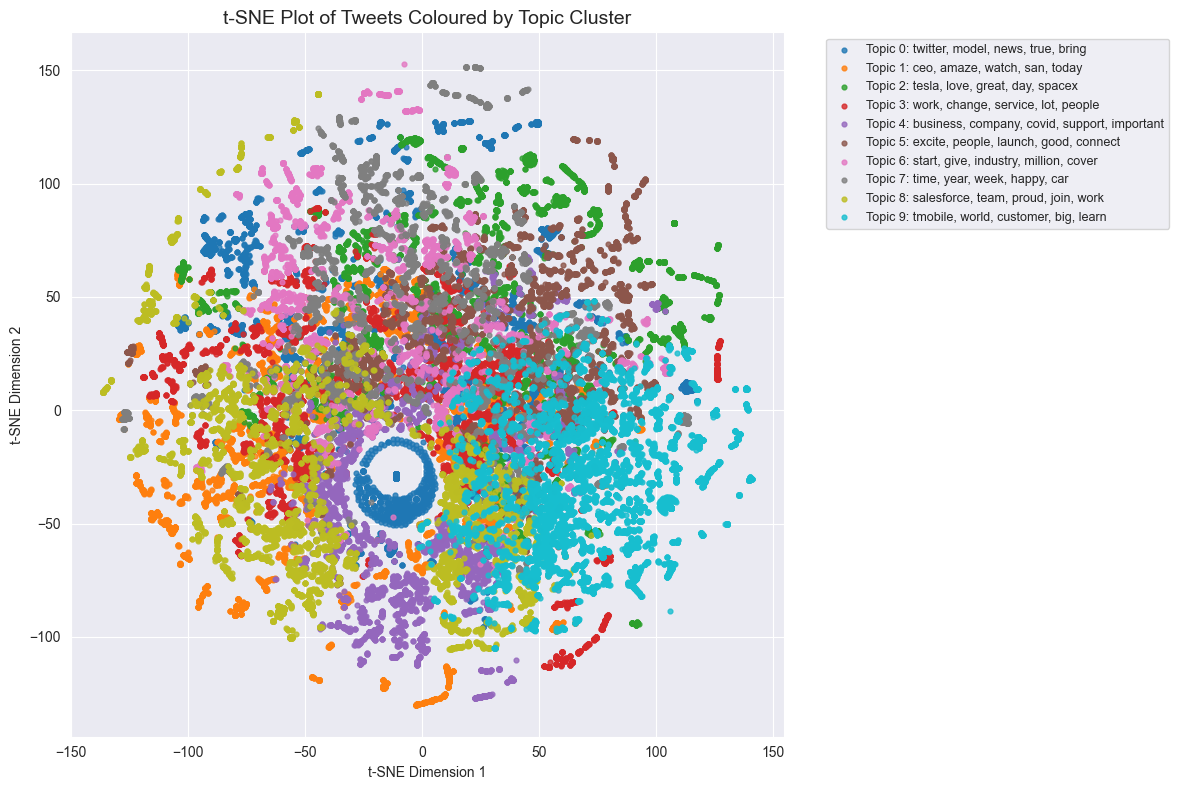

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- 1. Get topic distributions for each tweet ---
# dtm is your document-term matrix
topic_distributions = lda.transform(dtm)   # shape: (n_docs, n_topics)

# --- 2. Run t-SNE on topic vectors ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_coords = tsne.fit_transform(topic_distributions)

x = tsne_coords[:, 0]
y = tsne_coords[:, 1]

# --- 3. Assign each tweet to its highest-probability topic ---
clusters = np.argmax(topic_distributions, axis=1)

# --- 4. Extract top 5 words per cluster from LDA ---
top_words = {}
for topic_idx, topic in enumerate(lda.components_):
    top_word_indices = np.argsort(topic)[::-1][:5]
    top_words[topic_idx] = [feature_names[i] for i in top_word_indices]

# --- 5. Plot with distinct colours ---
plt.figure(figsize=(12, 8))

# Distinct colour map
cmap = plt.cm.get_cmap('tab10', lda.n_components)

for topic_idx in range(lda.n_components):
    mask = clusters == topic_idx
    plt.scatter(
        x[mask],
        y[mask],
        s=12,
        alpha=0.8,
        color=cmap(topic_idx),
        label=f"Topic {topic_idx}: " + ", ".join(top_words[topic_idx])
    )

plt.title("t-SNE Plot of Tweets Coloured by Topic Cluster", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


In [28]:
import numpy as np
import pandas as pd

# Load original tweets
df = pd.read_csv('tweets.csv')
original_tweets = df["text"].astype(str).tolist()  # ensure all entries are strings

# clusters = np.argmax(topic_distributions, axis=1)
num_samples = 3

for topic_idx in range(lda.n_components):
    # Indices of tweets assigned to this cluster
    cluster_indices = np.where(clusters == topic_idx)[0]

    print(f"\n--- Topic {topic_idx} (showing {num_samples} random original tweets) ---")

    if len(cluster_indices) == 0:
        print("No tweets in this cluster.")
        continue

    # Choose up to 3 random tweets (without replacement)
    selected = np.random.choice(cluster_indices, size=min(num_samples, len(cluster_indices)), replace=False)

    for idx in selected:
        print("-", original_tweets[idx])



--- Topic 0 (showing 3 random original tweets) ---
- RT @Benioff: Welcome Home @inspiration4x!
❤️🚀
- EuroInSC
- monitoringbias Sciencefiction ftw

--- Topic 1 (showing 3 random original tweets) ---
- Ken Frazier reminds us what a great ceo is!The most important role of a leader is to safeguard the heritage and values of the company. I actually dont see that big a conflict between meeting the needs of shareholders and meeting the needs of society.
- RT @PHassey: Louis Vuitton suit and watch and adidas joggers for @Benioff keynote. Who says tech isn’t in fashion #df17
- RT @Benioff: Join legendary Fleetwood Mac on November 20th at this year’s Concert for UCSF Benioff Children’s Hospitals at Oracle Park! Thi…

--- Topic 2 (showing 3 random original tweets) ---
- robbystarbuck Tesla Good point. Getting fixed 
- Tesla Model S estimated EPA range is now above 390 miles or 630 km
- RT @chefjoseandres: We are all Ukrainians right now 🇺🇦 It’s been a long day…but before I go to sleep here’s my 

In [17]:
import numpy as np
import pandas as pd

# Load original tweets
df = pd.read_csv('tweets.csv')
original_tweets = df["text"].astype(str).tolist()  # ensure all entries are strings

# Compute topic distributions if not already done
# topic_distributions = lda.transform(dtm)
# clusters = np.argmax(topic_distributions, axis=1)

representative_tweets = {}

for topic_idx in range(lda.n_components):
    # Get probability of this topic for all tweets
    topic_probs = topic_distributions[:, topic_idx]

    # Find the index of the tweet with the highest probability for this topic
    best_idx = np.argmax(topic_probs)

    representative_tweets[topic_idx] = original_tweets[best_idx]

# Print results
for topic_idx, tweet in representative_tweets.items():
    print(f"\n--- Topic {topic_idx} ---")
    print(tweet)



--- Topic 0 ---
RT @Forbes: The Ocean Cleanup plans to clean up 90% of the plastic that humanity has dumped in the oceans by 2040
https://t.co/fOMXQvx6SJ h…

--- Topic 1 ---
Amazing night in presidiosf with the moon overlooking our campfire.  A gorgeous San Francisco night!

--- Topic 2 ---
mattierogers aikatchu Tesla We could probably make a fun punch click buggy game, with extra points for rare Teslas

--- Topic 3 ---
We often forget that WE ARE NATURE. Nature is not something separate from us. So when we say that we have lost our connection to nature, weve lost our connection to ourselves. andygoldsworthy

--- Topic 4 ---
RT @JaredEMoskowitz: MASKS MASKS MASKS MASKS  MASKS MASKS MASKS MASKS MASKS MASKS MASKS MASKS MASKS MASKS MASKS MASKS  MASKS MASKS MASKS MA…

--- Topic 5 ---
Were sending 28 pallets of lifesaving ventilators to our ResMed team in India  thousands of devices to help with the latest Covid case surge in the country.  Thanks to our teams in Atlanta, Sydney, and Singap